# Week 7–8 — Stock Prediction with LSTM and RL (DQN & DDPG)

Final project: predict a stock's next adjusted closing price with three
models trained on the same features (log return, MACD, RSI):

1. **LSTM** — supervised benchmark, predicts the next-day log return.
2. **DQN** — prediction framed as RL: the action is the predicted return,
   picked from 7 quantile buckets.
3. **DDPG** — same idea with a continuous action.

The models are compared on R² and on returns/risk with a simple trading
backtest, all produce the required 15-day forecast, and the pipeline is
repeated on four tickers. A naive persistence baseline ("tomorrow = today")
is always included.


In [21]:
%matplotlib inline
import os
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # quiet TensorFlow logs
warnings.filterwarnings("ignore")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from cycler import cycler
from gymnasium import spaces
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (LSTM, Concatenate, Dense, Dropout,
                                     Input)
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()  # reproducible runs

print("TensorFlow", tf.__version__, "| gymnasium", gym.__version__,
      "| yfinance", yf.__version__)

TensorFlow 2.19.0 | gymnasium 1.3.0 | yfinance 1.4.1


In [22]:
# Plot styling: consistent palette, thin marks, recessive grid
COLORS = {
    "blue": "#2a78d6",    # series 1
    "aqua": "#1baf7a",    # series 2
    "yellow": "#eda100",  # series 3
    "green": "#008300",   # series 4
    "violet": "#4a3aa7",  # series 5
    "red": "#e34948",     # series 6
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781",
    "ytick.color": "#898781", "text.color": "#0b0b0b",
    "lines.linewidth": 2.0,
    "axes.prop_cycle": cycler(color=list(COLORS.values())),
    "figure.figsize": (12, 5), "savefig.dpi": 150,
    "savefig.bbox": "tight", "legend.frameon": False,
})


def save_fig(fig, name):
    """Save a copy of the figure next to the notebook."""
    fig.savefig(name)
    print(f"saved plot -> {name}")

## 1 — Data Collection (user input → `yfinance`)

Same input scheme as Week 5: ticker, date range and timeframe, with defaults
when running non-interactively.


In [3]:
TIMEFRAMES = {"daily": "1d", "weekly": "1wk", "monthly": "1mo"}
HOLDOUT_LEN = {"daily": 126, "weekly": 26, "monthly": 6}     # ~6 months
FINAL_LEN = {"daily": 30, "weekly": 6, "monthly": 2}         # ~6 weeks


def ask(prompt, default):
    """Prompt the user, falling back to the default when stdin is unavailable."""
    try:
        value = input(f"{prompt} [{default}]: ").strip()
        return value if value else default
    except Exception:
        print(f"{prompt} [{default}]: (input unavailable, using default)")
        return default


TODAY = pd.Timestamp.today().date().isoformat()
TICKER = ask("Stock ticker (e.g. AAPL, GOOGL)", "AAPL").upper()
START = ask("Start date (YYYY-MM-DD)", "2018-01-01")
END = ask("End date (YYYY-MM-DD)", TODAY)
TIMEFRAME = ask("Timeframe (daily / weekly / monthly)", "daily").lower()
assert TIMEFRAME in TIMEFRAMES, f"timeframe must be one of {list(TIMEFRAMES)}"

In [4]:
def compute_macd(close, fast=12, slow=26, signal=9):
    """MACD = EMA(fast) - EMA(slow); signal = EMA(MACD, signal)."""
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    return macd, macd_signal, macd - macd_signal


def compute_rsi(close, period=14):
    """Relative Strength Index using Wilder's smoothing."""
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / period, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / period, adjust=False).mean()
    return 100 - 100 / (1 + gain / loss)


def compute_bollinger(close, period=20, num_std=2):
    mid = close.rolling(period).mean()
    std = close.rolling(period).std()
    return mid, mid + num_std * std, mid - num_std * std


def fetch_stock(ticker):
    """Download + indicator pipeline, shared with the multi-stock section."""
    raw = yf.download(ticker, start=START, end=END,
                      interval=TIMEFRAMES[TIMEFRAME],
                      auto_adjust=False, progress=False)
    assert not raw.empty, f"No data returned for {ticker}."
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(1)
    if "Adj Close" not in raw.columns:
        raw["Adj Close"] = raw["Close"]
    c = raw["Adj Close"]
    raw["MACD"], raw["MACD_signal"], raw["MACD_hist"] = compute_macd(c)
    raw["RSI"] = compute_rsi(c)
    raw["BB_mid"], raw["BB_upper"], raw["BB_lower"] = compute_bollinger(c)
    raw["log_ret"] = np.log(c / c.shift(1))
    return raw


print(f"Downloading {TICKER} ({TIMEFRAME}) from {START} to {END} ...")
df = fetch_stock(TICKER)
data = df[["Adj Close", "MACD", "RSI", "log_ret"]].dropna()
print(f"Downloaded {len(df)} rows; {len(data)} usable "
      f"({data.index[0].date()} -> {data.index[-1].date()})")
df.tail(3)

Downloaded 2140 rows; 2139 usable (2018-01-03 -> 2026-07-09)


Price,Adj Close,Close,High,Low,Open,Volume,MACD,MACD_signal,MACD_hist,RSI,BB_mid,BB_upper,BB_lower,log_ret
Date,,,,,,,,,,,,,,
2026-07-07,310.660004,310.660004,315.480011,310.149994,315.290009,42490000,1.947661,-0.06125,2.008911,60.674812,295.039999,313.385270,276.694729,-0.006417
2026-07-08,313.390015,313.390015,314.820007,307.049988,311.910004,41323500,2.970296,0.54506,2.425237,62.247731,295.632500,315.558993,275.706007,0.008749
2026-07-09,316.220001,316.220001,316.529999,308.160004,310.445007,44882363,3.963411,1.22873,2.734681,63.861390,296.916000,318.685729,275.146272,0.008990


## 2 — Visualization: adjusted close + technical indicators

Bollinger Bands for volatility context; MACD and RSI are also the model
features.


saved plot -> 01_price_bollinger.png


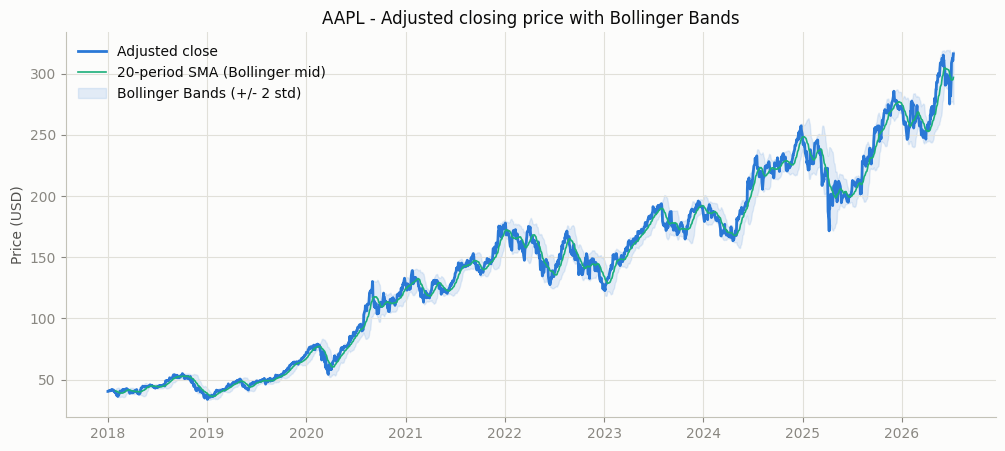

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Adj Close"], color=COLORS["blue"], label="Adjusted close")
ax.plot(df.index, df["BB_mid"], color=COLORS["aqua"], linewidth=1.2,
        label="20-period SMA (Bollinger mid)")
ax.fill_between(df.index, df["BB_lower"], df["BB_upper"],
                color=COLORS["blue"], alpha=0.12,
                label="Bollinger Bands (+/- 2 std)")
ax.set_title(f"{TICKER} - Adjusted closing price with Bollinger Bands")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "01_price_bollinger.png")
plt.show()

saved plot -> 02_macd.png


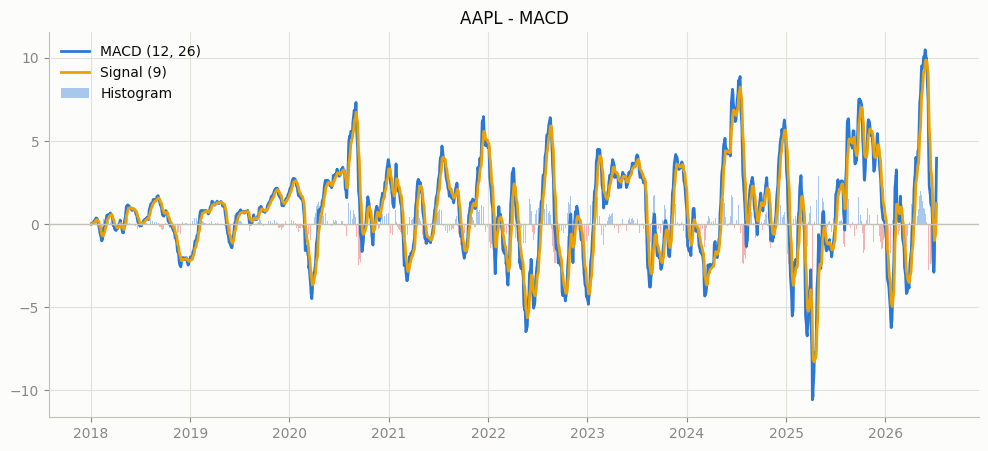

In [6]:
fig, ax = plt.subplots()
ax.plot(df.index, df["MACD"], color=COLORS["blue"], label="MACD (12, 26)")
ax.plot(df.index, df["MACD_signal"], color=COLORS["yellow"], label="Signal (9)")
hist_colors = np.where(df["MACD_hist"] >= 0, COLORS["blue"], COLORS["red"])
ax.bar(df.index, df["MACD_hist"], color=hist_colors, alpha=0.4, width=1.0,
       label="Histogram")
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_title(f"{TICKER} - MACD")
ax.legend()
save_fig(fig, "02_macd.png")
plt.show()

saved plot -> 03_rsi.png


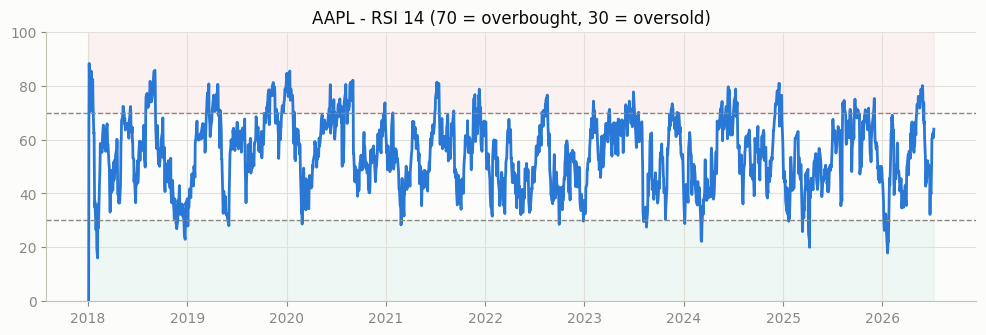

In [7]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df.index, df["RSI"], color=COLORS["blue"])
ax.axhline(70, color="#898781", linewidth=1, linestyle="--")
ax.axhline(30, color="#898781", linewidth=1, linestyle="--")
ax.fill_between(df.index, 70, 100, color=COLORS["red"], alpha=0.06)
ax.fill_between(df.index, 0, 30, color=COLORS["aqua"], alpha=0.06)
ax.set_ylim(0, 100)
ax.set_title(f"{TICKER} - RSI 14 (70 = overbought, 30 = oversold)")
save_fig(fig, "03_rsi.png")
plt.show()

## 3 — Data segmentation

Chronological split: the last ~6 months are held out for testing, and the
final 30 trading days (the assignment's "past 6 weeks") are reported
separately. All normalization statistics come from the training part only.


In [8]:
test_len = min(HOLDOUT_LEN[TIMEFRAME], len(data) // 4)
final_len = FINAL_LEN[TIMEFRAME]
test_start = len(data) - test_len

print(f"train: {data.index[0].date()} -> {data.index[test_start-1].date()} "
      f"({test_start} rows)")
print(f"test:  {data.index[test_start].date()} -> {data.index[-1].date()} "
      f"({test_len} rows, final {final_len} = 'past 6 weeks' window)")

train: 2018-01-03 -> 2026-01-06 (2013 rows)
test:  2026-01-07 -> 2026-07-09 (126 rows, final 30 = 'past 6 weeks' window)


## 4 — Benchmark model: LSTM

Predicts the next-day log return from 60-day windows; the price is rebuilt
as `previous close × exp(predicted return)`. Predicting returns keeps the
target stationary — predicting scaled price levels broke when the test
period traded above the training range.


train windows: (1953, 60, 3), test windows: (126, 60, 3)
Epoch 1/40


2026-07-10 01:43:50.871678: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-07-10 01:43:51.106289: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


55/55 - 3s - 54ms/step - loss: 1.0001 - val_loss: 1.1783
Epoch 2/40
55/55 - 1s - 23ms/step - loss: 0.9912 - val_loss: 1.1814
Epoch 3/40
55/55 - 1s - 25ms/step - loss: 0.9939 - val_loss: 1.1642
Epoch 4/40
55/55 - 1s - 23ms/step - loss: 0.9969 - val_loss: 1.1638
Epoch 5/40
55/55 - 1s - 24ms/step - loss: 0.9924 - val_loss: 1.1528
Epoch 6/40
55/55 - 1s - 25ms/step - loss: 0.9977 - val_loss: 1.1530
Epoch 7/40
55/55 - 1s - 23ms/step - loss: 0.9907 - val_loss: 1.1568
Epoch 8/40
55/55 - 1s - 25ms/step - loss: 0.9869 - val_loss: 1.1574
Epoch 9/40
55/55 - 1s - 23ms/step - loss: 0.9812 - val_loss: 1.1576
Epoch 10/40
55/55 - 1s - 24ms/step - loss: 0.9802 - val_loss: 1.1641
Epoch 11/40
55/55 - 1s - 22ms/step - loss: 0.9866 - val_loss: 1.1516
Epoch 12/40
55/55 - 1s - 20ms/step - loss: 0.9825 - val_loss: 1.1544
Epoch 13/40
55/55 - 1s - 25ms/step - loss: 0.9757 - val_loss: 1.1533
Epoch 14/40
55/55 - 1s - 20ms/step - loss: 0.9792 - val_loss: 1.1474
Epoch 15/40
55/55 - 1s - 20ms/step - loss: 0.9816 - va

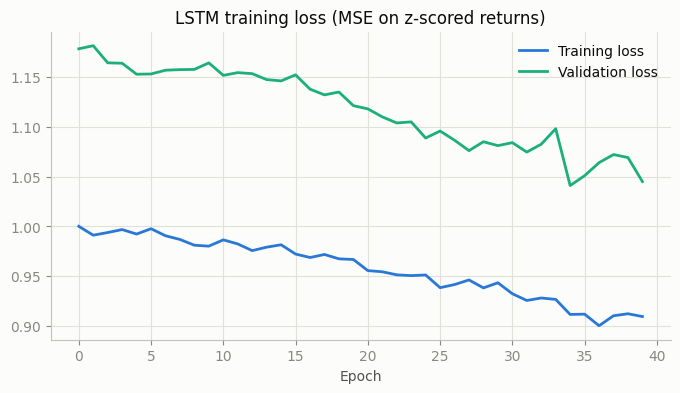

In [9]:
LSTM_WINDOW = 60
LSTM_FEATURES = ["log_ret", "MACD", "RSI"]


def make_lstm_dataset(data_, test_start_):
    """Windowed dataset with z-scored features and a z-scored next-day
    log-return target; all statistics come from the training segment only."""
    feats = data_[LSTM_FEATURES].values
    mu_f, sd_f = feats[:test_start_].mean(0), feats[:test_start_].std(0)
    sf = (feats - mu_f) / sd_f
    lr = data_["log_ret"].values
    mu_r, sd_r = lr[:test_start_].mean(), lr[:test_start_].std()
    st = (lr - mu_r) / sd_r
    Xs, ys = [], []
    for i in range(LSTM_WINDOW, len(data_)):
        Xs.append(sf[i - LSTM_WINDOW:i])
        ys.append(st[i])
    Xs, ys = np.array(Xs), np.array(ys)
    sp = test_start_ - LSTM_WINDOW
    norm = {"mu_f": mu_f, "sd_f": sd_f, "mu_r": mu_r, "sd_r": sd_r}
    return norm, Xs[:sp], ys[:sp], Xs[sp:], ys[sp:]


def fit_lstm(X_tr, y_tr, verbose=0):
    m = Sequential([
        Input(shape=(LSTM_WINDOW, len(LSTM_FEATURES))),
        LSTM(64, return_sequences=True), Dropout(0.2),
        LSTM(32), Dropout(0.2), Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    h = m.fit(X_tr, y_tr, epochs=40, batch_size=32, validation_split=0.1,
              verbose=verbose,
              callbacks=[EarlyStopping(monitor="val_loss", patience=6,
                                       restore_best_weights=True)])
    return m, h


lstm_norm, X_train, y_train, X_test, y_test = make_lstm_dataset(data,
                                                                test_start)
print(f"train windows: {X_train.shape}, test windows: {X_test.shape}")

lstm, history = fit_lstm(X_train, y_train, verbose=2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], color=COLORS["blue"], label="Training loss")
ax.plot(history.history["val_loss"], color=COLORS["aqua"],
        label="Validation loss")
ax.set_title("LSTM training loss (MSE on z-scored returns)")
ax.set_xlabel("Epoch")
ax.legend()
save_fig(fig, "04_lstm_training_loss.png")
plt.show()

In [10]:
prev_close_test = data["Adj Close"].values[test_start - 1:-1]
true_test = data["Adj Close"].values[test_start:]
test_dates = data.index[test_start:]

pred_ret_lstm = (lstm.predict(X_test, verbose=0).ravel()
                 * lstm_norm["sd_r"] + lstm_norm["mu_r"])
lstm_pred = prev_close_test * np.exp(pred_ret_lstm)

print(f"LSTM R2 (6-month holdout): {r2_score(true_test, lstm_pred):.4f}")
print(f"LSTM MAE (holdout): ${mean_absolute_error(true_test, lstm_pred):.2f}")

2026-07-10 01:44:42.454099: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


LSTM R2 (6-month holdout): 0.9493
LSTM MAE (holdout): $3.38


## 5 — RL models: prediction as an RL problem

A custom `gymnasium` environment: the state is the last 10 days of
normalized features, the action encodes the predicted next-day return
(7 discrete buckets for DQN, one continuous value for DDPG) and the reward
is the negative prediction error. The reward is immediate and the action
doesn't affect the next state, so γ = 0.


In [11]:
class PredictionEnvBase(gym.Env):
    """Next-return prediction environment.

    The observation at step t contains features up to and including day t-1;
    the action encodes a predicted log return for day t and the reward is the
    negative absolute prediction error (x100)."""

    def __init__(self, features, log_rets, window=10):
        super().__init__()
        self.features, self.log_rets = features, log_rets
        self.window = window
        n_obs = window * features.shape[1]
        self.observation_space = spaces.Box(-np.inf, np.inf, (n_obs,),
                                            np.float32)

    def _obs(self):
        return self.features[self.t - self.window:self.t].ravel().astype(
            np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = self.window
        return self._obs(), {}

    def _score(self, pred_ret):
        true_ret = self.log_rets[self.t]
        reward = -abs(pred_ret - true_ret) * 100
        self.t += 1
        done = self.t >= len(self.log_rets)
        obs = self._obs() if not done else np.zeros(
            self.observation_space.shape, np.float32)
        return obs, float(reward), done, False, \
            {"pred_ret": pred_ret, "true_ret": true_ret}


class BucketPredictionEnv(PredictionEnvBase):
    """DQN variant - discrete actions, one per candidate return bucket."""

    def __init__(self, features, log_rets, buckets, window=10):
        super().__init__(features, log_rets, window)
        self.buckets = buckets
        self.action_space = spaces.Discrete(len(buckets))

    def step(self, action):
        return self._score(float(self.buckets[int(action)]))


class ContinuousPredictionEnv(PredictionEnvBase):
    """DDPG variant - action in [-1, 1] scaled to +/- max_ret."""

    def __init__(self, features, log_rets, max_ret, window=10):
        super().__init__(features, log_rets, window)
        self.max_ret = max_ret
        self.action_space = spaces.Box(-1.0, 1.0, (1,), np.float32)

    def step(self, action):
        a = float(np.clip(np.asarray(action).ravel()[0], -1.0, 1.0))
        return self._score(a * self.max_ret)


RL_WINDOW = 10
OBS_DIM = RL_WINDOW * 3
N_BUCKETS = 7


def make_envs(data_, test_start_):
    """Train/test env pairs (both action types) for one stock."""
    raw = data_[["log_ret", "MACD", "RSI"]].values
    mu_, sd_ = raw[:test_start_].mean(0), raw[:test_start_].std(0)
    feat = (raw - mu_) / sd_  # normalized with training stats only
    lr = data_["log_ret"].values
    train_lr = lr[:test_start_]
    # candidate returns: quantiles of the TRAINING return distribution
    buckets = np.quantile(train_lr, np.linspace(0.05, 0.95, N_BUCKETS))
    max_ret = 3 * train_lr.std()
    mk = lambda cls, arg, lo, hi: cls(feat[lo:hi], lr[lo:hi], arg)
    return {"train_d": mk(BucketPredictionEnv, buckets, 0, test_start_),
            "test_d": mk(BucketPredictionEnv, buckets,
                         test_start_ - RL_WINDOW, None),
            "train_c": mk(ContinuousPredictionEnv, max_ret, 0, test_start_),
            "test_c": mk(ContinuousPredictionEnv, max_ret,
                         test_start_ - RL_WINDOW, None),
            "norm": (mu_, sd_), "buckets": buckets, "max_ret": max_ret}


envs = make_envs(data, test_start)
print("observation dim:", OBS_DIM)
print("DQN return buckets (%):", np.round(envs["buckets"] * 100, 2))
print(f"DDPG return range: +/-{envs['max_ret']:.3%}")

observation dim: 30
DQN return buckets (%): [-3.02 -1.06 -0.37  0.12  0.63  1.36  2.9 ]
DDPG return range: +/-5.809%


In [12]:
# gamma = 0: the reward is immediate and the action does not affect the
# next state, so there is nothing to bootstrap
GAMMA, BATCH, BUFFER_CAP, TRAIN_EVERY, TAU = 0.0, 64, 20000, 4, 0.01
EPISODES = 25


class ReplayBuffer:
    """Fixed-size ring buffer of (s, a, r, s2, done) transitions."""

    def __init__(self, cap, obs_dim, act_dim=1):
        self.cap, self.n = cap, 0
        self.s = np.zeros((cap, obs_dim), np.float32)
        self.a = np.zeros((cap, act_dim), np.float32)
        self.r = np.zeros(cap, np.float32)
        self.s2 = np.zeros((cap, obs_dim), np.float32)
        self.d = np.zeros(cap, np.float32)

    def add(self, s, a, r, s2, d):
        i = self.n % self.cap
        self.s[i], self.a[i], self.r[i], self.s2[i], self.d[i] = s, a, r, s2, d
        self.n += 1

    def sample(self, rng, batch):
        idx = rng.integers(0, min(self.n, self.cap), batch)
        return (self.s[idx], self.a[idx], self.r[idx], self.s2[idx],
                self.d[idx])


class DQNAgent:
    """Deep Q-Network with replay + soft-updated target network."""

    def __init__(self, obs_dim=OBS_DIM, n_actions=N_BUCKETS, lr=1e-3,
                 seed=42):
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)
        mk = lambda: Sequential([Input(shape=(obs_dim,)),
                                 Dense(64, activation="relu"),
                                 Dense(64, activation="relu"),
                                 Dense(n_actions)])
        self.q, self.q_tgt = mk(), mk()
        self.q_tgt.set_weights(self.q.get_weights())
        self.opt = tf.keras.optimizers.Adam(lr)
        self.buf = ReplayBuffer(BUFFER_CAP, obs_dim)
        self._q_fast = tf.function(self.q)  # compiled forward pass

    @tf.function
    def _train(self, s, a, r, s2, d):
        q_next = tf.reduce_max(self.q_tgt(s2), axis=1)
        target = r + GAMMA * q_next * (1.0 - d)
        with tf.GradientTape() as tape:
            q = tf.reduce_sum(self.q(s) * tf.one_hot(
                tf.cast(a[:, 0], tf.int32), self.n_actions), axis=1)
            loss = tf.reduce_mean(tf.square(target - q))
        grads = tape.gradient(loss, self.q.trainable_variables)
        self.opt.apply_gradients(zip(grads, self.q.trainable_variables))
        for w, tw in zip(self.q.trainable_variables,
                         self.q_tgt.trainable_variables):
            tw.assign(TAU * w + (1 - TAU) * tw)

    def act(self, obs, eps=0.0):
        if self.rng.random() < eps:
            return int(self.rng.integers(self.n_actions))
        return int(np.argmax(self._q_fast(obs[None])[0]))

    def train(self, env, episodes=EPISODES, log_every=0):
        steps_per_ep = len(env.log_rets) - env.window
        eps_decay = int(episodes * steps_per_ep * 0.6)
        gstep, rewards = 0, []
        for ep in range(episodes):
            obs, _ = env.reset()
            ep_r, done = 0.0, False
            while not done:
                eps = max(0.05, 1.0 - 0.95 * gstep / eps_decay)
                a = self.act(obs, eps)
                obs2, r, done, _, _ = env.step(a)
                self.buf.add(obs, [a], r, obs2, float(done))
                obs = obs2
                ep_r += r
                gstep += 1
                if gstep % TRAIN_EVERY == 0 and self.buf.n >= 1000:
                    self._train(*self.buf.sample(self.rng, BATCH))
            rewards.append(ep_r)
            if log_every and (ep + 1) % log_every == 0:
                print(f"  DQN  episode {ep+1:3d}/{episodes}: "
                      f"reward {ep_r:9.2f}, epsilon {eps:.2f}")
        return rewards

    def predicted_return(self, env, obs):
        return float(env.buckets[self.act(obs, 0.0)])


class DDPGAgent:
    """Deep Deterministic Policy Gradient: actor outputs the predicted
    return (via tanh, scaled by the env); critic scores (state, action)."""

    def __init__(self, obs_dim=OBS_DIM, actor_lr=5e-4, critic_lr=1e-3,
                 seed=42):
        self.rng = np.random.default_rng(seed)

        def mk_actor():
            return Sequential([Input(shape=(obs_dim,)),
                               Dense(64, activation="relu"),
                               Dense(64, activation="relu"),
                               Dense(1, activation="tanh")])

        def mk_critic():
            s_in, a_in = Input(shape=(obs_dim,)), Input(shape=(1,))
            x = Concatenate()([s_in, a_in])
            x = Dense(64, activation="relu")(x)
            x = Dense(64, activation="relu")(x)
            return Model([s_in, a_in], Dense(1)(x))

        self.actor, self.actor_tgt = mk_actor(), mk_actor()
        self.critic, self.critic_tgt = mk_critic(), mk_critic()
        self.actor_tgt.set_weights(self.actor.get_weights())
        self.critic_tgt.set_weights(self.critic.get_weights())
        self.a_opt = tf.keras.optimizers.Adam(actor_lr)
        self.c_opt = tf.keras.optimizers.Adam(critic_lr)
        self.buf = ReplayBuffer(BUFFER_CAP, obs_dim)
        self._pi_fast = tf.function(self.actor)  # compiled forward pass

    @tf.function
    def _train(self, s, a, r, s2, d):
        # critic: fit the immediate reward (gamma = 0)
        a2 = self.actor_tgt(s2)
        q2 = tf.squeeze(self.critic_tgt([s2, a2]), 1)
        target = r + GAMMA * q2 * (1.0 - d)
        with tf.GradientTape() as tape:
            q = tf.squeeze(self.critic([s, a]), 1)
            c_loss = tf.reduce_mean(tf.square(target - q))
        grads = tape.gradient(c_loss, self.critic.trainable_variables)
        self.c_opt.apply_gradients(zip(grads, self.critic.trainable_variables))
        # actor: gradient ascent on the critic's valuation of its actions
        with tf.GradientTape() as tape:
            a_loss = -tf.reduce_mean(self.critic([s, self.actor(s)]))
        grads = tape.gradient(a_loss, self.actor.trainable_variables)
        self.a_opt.apply_gradients(zip(grads, self.actor.trainable_variables))
        for net, tgt in [(self.actor, self.actor_tgt),
                         (self.critic, self.critic_tgt)]:
            for w, tw in zip(net.trainable_variables, tgt.trainable_variables):
                tw.assign(TAU * w + (1 - TAU) * tw)

    def act(self, obs, noise=0.0):
        a = float(self._pi_fast(obs[None])[0, 0])
        if noise > 0:
            a += self.rng.normal(0, noise)
        return float(np.clip(a, -1.0, 1.0))

    def train(self, env, episodes=EPISODES, log_every=0):
        steps_per_ep = len(env.log_rets) - env.window
        noise_decay = int(episodes * steps_per_ep * 0.6)
        gstep, rewards = 0, []
        for ep in range(episodes):
            obs, _ = env.reset()
            ep_r, done = 0.0, False
            while not done:
                noise = max(0.05, 0.3 - 0.25 * gstep / noise_decay)
                a = self.act(obs, noise)
                obs2, r, done, _, _ = env.step(a)
                self.buf.add(obs, [a], r, obs2, float(done))
                obs = obs2
                ep_r += r
                gstep += 1
                if gstep % TRAIN_EVERY == 0 and self.buf.n >= 1000:
                    self._train(*self.buf.sample(self.rng, BATCH))
            rewards.append(ep_r)
            if log_every and (ep + 1) % log_every == 0:
                print(f"  DDPG episode {ep+1:3d}/{episodes}: "
                      f"reward {ep_r:9.2f}, noise {noise:.2f}")
        return rewards

    def predicted_return(self, env, obs):
        return self.act(obs, 0.0) * env.max_ret

Training DQN ...
  DQN  episode   5/25: reward  -3540.22, epsilon 0.68
  DQN  episode  10/25: reward  -3063.60, epsilon 0.37
  DQN  episode  15/25: reward  -2463.86, epsilon 0.05
  DQN  episode  20/25: reward  -2292.01, epsilon 0.05
  DQN  episode  25/25: reward  -2102.92, epsilon 0.05
Training DDPG ...
  DDPG episode   5/25: reward  -3399.54, noise 0.22
  DDPG episode  10/25: reward  -2894.62, noise 0.13
  DDPG episode  15/25: reward  -2386.09, noise 0.05
  DDPG episode  20/25: reward  -2314.98, noise 0.05
  DDPG episode  25/25: reward  -2287.71, noise 0.05
saved plot -> 07_rl_training.png


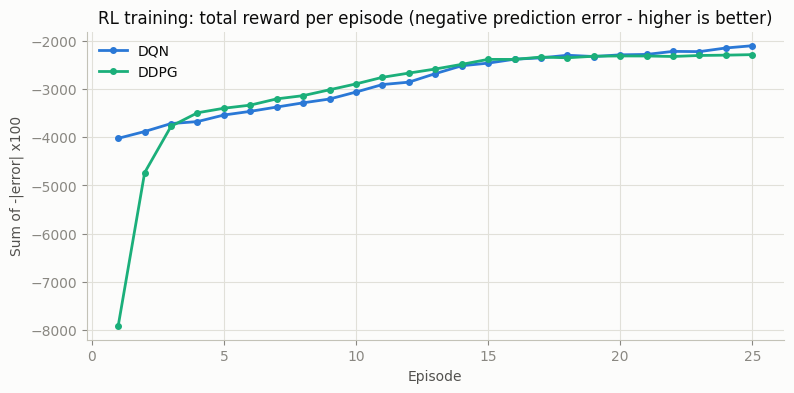

In [13]:
print("Training DQN ...")
dqn = DQNAgent()
dqn_curve = dqn.train(envs["train_d"], log_every=5)

print("Training DDPG ...")
ddpg = DDPGAgent()
ddpg_curve = ddpg.train(envs["train_c"], log_every=5)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EPISODES + 1), dqn_curve, color=COLORS["blue"], marker="o",
        markersize=4, label="DQN")
ax.plot(range(1, EPISODES + 1), ddpg_curve, color=COLORS["aqua"], marker="o",
        markersize=4, label="DDPG")
ax.set_title("RL training: total reward per episode "
             "(negative prediction error - higher is better)")
ax.set_xlabel("Episode")
ax.set_ylabel("Sum of -|error| x100")
ax.legend()
save_fig(fig, "07_rl_training.png")
plt.show()

## 6 — R² comparison on the held-out test period

Each agent is rolled through the test set greedily, its predicted returns
are turned into prices, and all models are scored with R² next to the
persistence baseline.


In [14]:
def rl_predictions(env, agent):
    """Greedy rollout; returns the predicted price series for the test days."""
    obs, _ = env.reset()
    preds, done = [], False
    while not done:
        pred_ret = agent.predicted_return(env, obs)
        obs, _, done, _, info = env.step(
            pred_ret / env.max_ret if hasattr(env, "max_ret")
            else int(np.argmin(np.abs(env.buckets - pred_ret))))
        preds.append(info["pred_ret"])
    prev = data["Adj Close"].values[test_start - 1:-1]
    return prev * np.exp(np.array(preds))


dqn_pred = rl_predictions(envs["test_d"], dqn)
ddpg_pred = rl_predictions(envs["test_c"], ddpg)
naive_pred = data["Adj Close"].values[test_start - 1:-1]

predictions = {"LSTM": lstm_pred, "DQN": dqn_pred, "DDPG": ddpg_pred,
               "Persistence (naive)": naive_pred}

r2_rows = []
for name, pred in predictions.items():
    r2_rows.append({
        "model": name,
        "R2 (6-month holdout)": r2_score(true_test, pred),
        f"R2 (final {final_len} days)": r2_score(true_test[-final_len:],
                                                 pred[-final_len:]),
        "MAE $ (holdout)": mean_absolute_error(true_test, pred)})
r2_table = pd.DataFrame(r2_rows).set_index("model")
display(r2_table.round(4))

,R2 (6-month holdout),R2 (final 30 days),MAE $ (holdout)
model,,,
LSTM,0.9493,0.6829,3.3820
DQN,0.9467,0.7034,3.5472
DDPG,0.9317,0.4990,3.7804
Persistence (naive),0.9486,0.6751,3.3849


saved plot -> 08_predictions_all_models.png


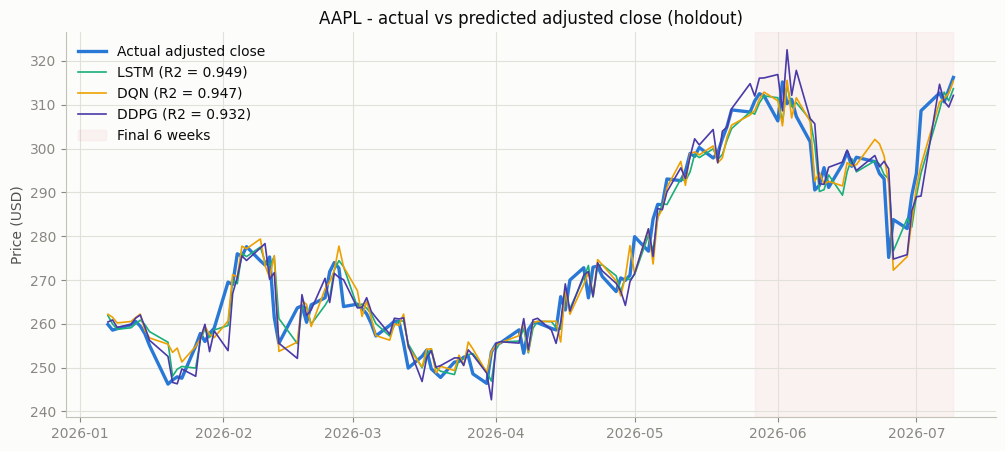

In [15]:
fig, ax = plt.subplots()
ax.plot(test_dates, true_test, color=COLORS["blue"], linewidth=2.4,
        label="Actual adjusted close")
for (name, pred), color in zip(list(predictions.items())[:3],
                               ["aqua", "yellow", "violet"]):
    ax.plot(test_dates, pred, color=COLORS[color], linewidth=1.2,
            label=f"{name} (R2 = {r2_score(true_test, pred):.3f})")
ax.axvspan(test_dates[-final_len], test_dates[-1], color=COLORS["red"],
           alpha=0.05, label="Final 6 weeks")
ax.set_title(f"{TICKER} - actual vs predicted adjusted close (holdout)")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "08_predictions_all_models.png")
plt.show()

## 7 — Returns & risk: trading backtest

R² only measures prediction accuracy, so each model is also turned into a
simple strategy: hold the stock on days the model predicts a positive
return, stay in cash otherwise (no shorting, no transaction costs).
Reported over the holdout: cumulative and annualized return, volatility,
Sharpe ratio, max drawdown, hit rate and number of position changes, next to
a buy & hold benchmark. Persistence predicts a zero return, so it produces
no strategy at all.


In [16]:
PERIODS_PER_YEAR = {"daily": 252, "weekly": 52, "monthly": 12}[TIMEFRAME]
actual_lr_test = np.log(true_test / prev_close_test)


def backtest(pred_lr, actual_lr):
    """Long/flat backtest: hold the stock on days with a positive predicted
    return, cash otherwise. pred_lr[t] is the model's predicted log return
    for test day t, made using information through day t-1 only."""
    pos = (pred_lr > 0).astype(float)
    strat_lr = pos * actual_lr
    equity = np.exp(np.cumsum(strat_lr))
    drawdown = equity / np.maximum.accumulate(equity) - 1
    sd, ppy = strat_lr.std(), PERIODS_PER_YEAR
    return equity, {
        "Cumulative return %": (equity[-1] - 1) * 100,
        "Annualized return %": (np.exp(strat_lr.mean() * ppy) - 1) * 100,
        "Annualized volatility %": sd * np.sqrt(ppy) * 100,
        "Sharpe ratio": strat_lr.mean() / sd * np.sqrt(ppy) if sd > 0
                        else np.nan,
        "Max drawdown %": drawdown.min() * 100,
        "Hit rate %": (np.sign(pred_lr) == np.sign(actual_lr)).mean() * 100,
        "Position changes": int(np.abs(np.diff(pos)).sum()),
    }


equity_curves, risk_rows = {}, {}
for name, pred in list(predictions.items())[:3]:          # LSTM, DQN, DDPG
    equity_curves[name], risk_rows[name] = backtest(
        np.log(pred / prev_close_test), actual_lr_test)
equity_curves["Buy & hold"], risk_rows["Buy & hold"] = backtest(
    np.ones_like(actual_lr_test), actual_lr_test)          # always long

risk_table = pd.DataFrame(risk_rows).T
print("=== Returns & risk on the 6-month holdout (long/flat rule) ===")
display(risk_table.round(2))


=== Returns & risk on the 6-month holdout (long/flat rule) ===


,Cumulative return %,Annualized return %,Annualized volatility %,Sharpe ratio,Max drawdown %,Hit rate %,Position changes
LSTM,20.12,44.28,23.00,1.59,-10.22,50.79,15.0
DQN,31.36,72.57,20.58,2.65,-7.55,58.73,52.0
DDPG,19.05,41.74,18.54,1.88,-9.84,56.35,52.0
Buy & hold,20.75,45.81,26.47,1.42,-12.71,53.97,0.0


saved plot -> 11_equity_curves.png


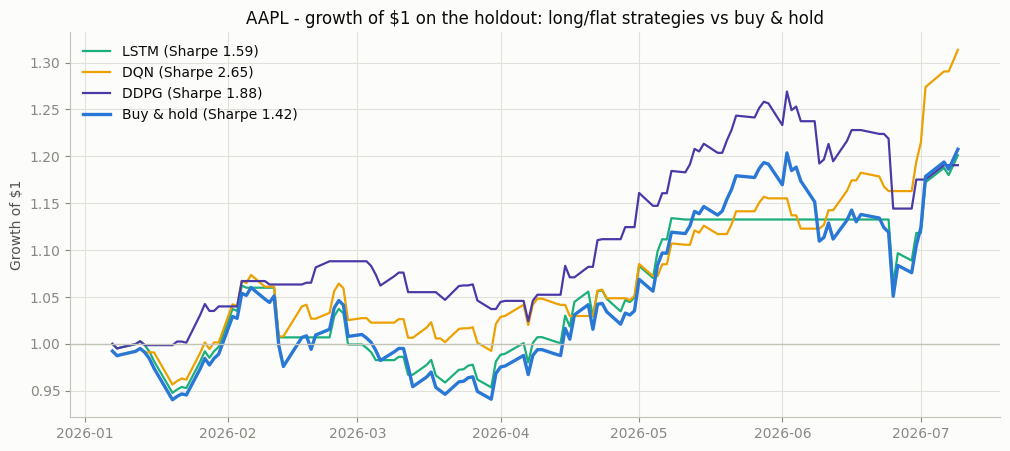

In [17]:
fig, ax = plt.subplots()
for name, color in zip(equity_curves, ["aqua", "yellow", "violet", "blue"]):
    ax.plot(test_dates, equity_curves[name], color=COLORS[color],
            linewidth=2.4 if name == "Buy & hold" else 1.6,
            label=f"{name} (Sharpe "
                  f"{risk_table.loc[name, 'Sharpe ratio']:.2f})")
ax.axhline(1.0, color="#c3c2b7", linewidth=1)
ax.set_title(f"{TICKER} - growth of $1 on the holdout: "
             "long/flat strategies vs buy & hold")
ax.set_ylabel("Growth of $1")
ax.legend()
save_fig(fig, "11_equity_curves.png")
plt.show()


## 8 — 15-day forecasts from all three models

Recursive: each predicted close is appended to the history and the
indicators are recomputed before the next step. Errors compound, so the
curves drift with the recent trend.


2026-07-10 01:46:19.660552: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


saved plot -> 09_forecasts_15day.png


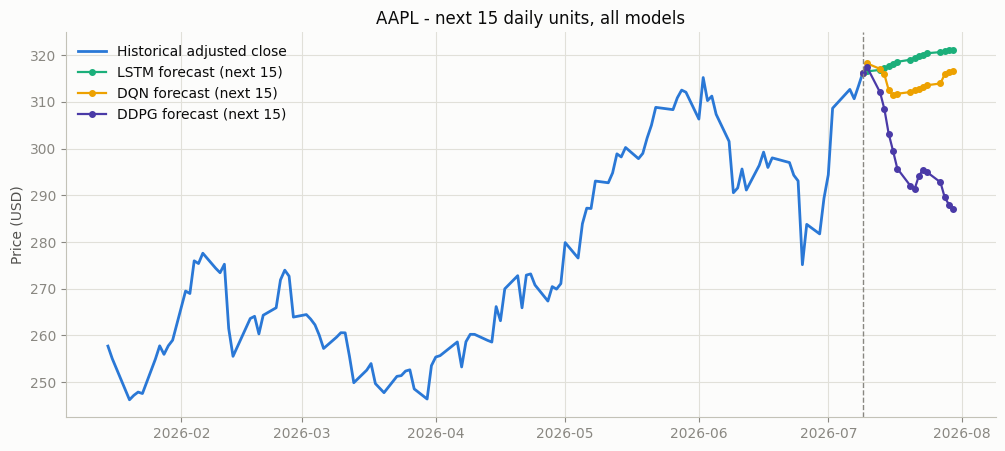

,LSTM,DQN,DDPG
2026-07-10,316.51,318.22,317.40
2026-07-13,316.84,317.04,312.04
2026-07-14,317.21,315.87,308.47
2026-07-15,317.64,312.52,303.18
2026-07-16,318.10,311.36,299.55
2026-07-17,318.56,311.73,295.72
2026-07-20,319.01,312.10,292.08
2026-07-21,319.43,312.46,291.30
2026-07-22,319.80,312.83,294.17
2026-07-23,320.13,313.20,295.50


In [18]:
def recursive_forecast(predict_price, steps=15):
    """predict_price(history_close) -> next price; iterate `steps` times."""
    fclose = data["Adj Close"].copy()
    for _ in range(steps):
        fclose.loc[fclose.index[-1] + pd.Timedelta(days=1)] = \
            predict_price(fclose)
    step_offset = {"daily": pd.tseries.offsets.BDay(1),
                   "weekly": pd.DateOffset(weeks=1),
                   "monthly": pd.DateOffset(months=1)}[TIMEFRAME]
    dates, d = [], data.index[-1]
    for _ in range(steps):
        d = d + step_offset
        dates.append(d)
    return pd.Series(fclose.values[-steps:], index=dates)


def lstm_next_price(fclose):
    macd, _, _ = compute_macd(fclose)
    rsi = compute_rsi(fclose)
    lr = np.log(fclose / fclose.shift(1))
    feats = np.column_stack([lr, macd, rsi])[-LSTM_WINDOW:]
    sf = (feats - lstm_norm["mu_f"]) / lstm_norm["sd_f"]
    pred = (lstm.predict(sf.reshape(1, LSTM_WINDOW, -1), verbose=0)[0, 0]
            * lstm_norm["sd_r"] + lstm_norm["mu_r"])
    return fclose.iloc[-1] * np.exp(pred)


def rl_next_price(agent, env):
    mu_, sd_ = envs["norm"]

    def _predict(fclose):
        macd, _, _ = compute_macd(fclose)
        rsi = compute_rsi(fclose)
        lr = np.log(fclose / fclose.shift(1))
        feat = (np.column_stack([lr, macd, rsi]) - mu_) / sd_
        obs = feat[-RL_WINDOW:].ravel().astype(np.float32)
        return fclose.iloc[-1] * np.exp(agent.predicted_return(env, obs))

    return _predict


forecasts = {
    "LSTM": recursive_forecast(lstm_next_price),
    "DQN": recursive_forecast(rl_next_price(dqn, envs["test_d"])),
    "DDPG": recursive_forecast(rl_next_price(ddpg, envs["test_c"])),
}

recent = data["Adj Close"].iloc[-120:]
fig, ax = plt.subplots()
ax.plot(recent.index, recent.values, color=COLORS["blue"],
        label="Historical adjusted close")
for (name, fc), color in zip(forecasts.items(), ["aqua", "yellow", "violet"]):
    joined = pd.concat([recent.iloc[-1:], fc])
    ax.plot(joined.index, joined.values, color=COLORS[color], marker="o",
            markersize=4, linewidth=1.6, label=f"{name} forecast (next 15)")
ax.axvline(recent.index[-1], color="#898781", linewidth=1, linestyle="--")
ax.set_title(f"{TICKER} - next 15 {TIMEFRAME} units, all models")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "09_forecasts_15day.png")
plt.show()

pd.DataFrame(forecasts).round(2)

## 9 — Robustness: four tickers

The same pipeline (same features, windows, hyperparameters, seed) is
repeated on GOOGL, MSFT and TSLA, and both comparisons — R² and Sharpe —
are collected per ticker.


In [19]:
EXTRA_TICKERS = ["GOOGL", "MSFT", "TSLA"]


def run_ticker_pipeline(ticker):
    """Full LSTM + DQN + DDPG prediction pipeline for one ticker."""
    d_ = fetch_stock(ticker)[["Adj Close", "MACD", "RSI", "log_ret"]].dropna()
    ts_ = len(d_) - min(HOLDOUT_LEN[TIMEFRAME], len(d_) // 4)
    tt_ = d_["Adj Close"].values[ts_:]
    prev_ = d_["Adj Close"].values[ts_ - 1:-1]

    n_, Xtr, ytr, Xte, yte = make_lstm_dataset(d_, ts_)
    m_, _ = fit_lstm(Xtr, ytr)
    pr_ = m_.predict(Xte, verbose=0).ravel() * n_["sd_r"] + n_["mu_r"]
    lp_ = prev_ * np.exp(pr_)

    e_ = make_envs(d_, ts_)
    dq_ = DQNAgent()
    dq_.train(e_["train_d"])
    dd_ = DDPGAgent()
    dd_.train(e_["train_c"])

    def rl_pred(env, agent):
        obs, _ = env.reset()
        preds, done = [], False
        while not done:
            pr = agent.predicted_return(env, obs)
            obs, _, done, _, info = env.step(
                pr / env.max_ret if hasattr(env, "max_ret")
                else int(np.argmin(np.abs(env.buckets - pr))))
            preds.append(info["pred_ret"])
        return prev_ * np.exp(np.array(preds))

    preds_ = {"LSTM": lp_, "DQN": rl_pred(e_["test_d"], dq_),
              "DDPG": rl_pred(e_["test_c"], dd_)}
    r2_ = {n: r2_score(tt_, p) for n, p in preds_.items()}
    r2_["Persistence (naive)"] = r2_score(tt_, prev_)
    alr_ = np.log(tt_ / prev_)
    sharpe_ = {n: backtest(np.log(p / prev_), alr_)[1]["Sharpe ratio"]
               for n, p in preds_.items()}
    sharpe_["Buy & hold"] = backtest(np.ones_like(alr_),
                                     alr_)[1]["Sharpe ratio"]
    return r2_, sharpe_


r2_by_ticker = {TICKER: {n: r2_score(true_test, p)
                         for n, p in predictions.items()}}
sharpe_by_ticker = {TICKER: risk_table["Sharpe ratio"].to_dict()}
for tk in EXTRA_TICKERS:
    print(f"Running full pipeline on {tk} ...")
    r2_by_ticker[tk], sharpe_by_ticker[tk] = run_ticker_pipeline(tk)

r2_summary = pd.DataFrame(r2_by_ticker).T
r2_summary.index.name = "ticker"
print("\n=== R2 on the 6-month holdout, all tickers ===")
display(r2_summary.round(4))

sharpe_summary = pd.DataFrame(sharpe_by_ticker).T
sharpe_summary.index.name = "ticker"
print("=== Sharpe (long/flat backtest) on the holdout, all tickers ===")
display(sharpe_summary.round(2))

Running full pipeline on GOOGL ...


2026-07-10 01:46:33.389011: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Running full pipeline on MSFT ...


2026-07-10 01:48:22.505018: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-10 01:49:03.513998: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Running full pipeline on TSLA ...


2026-07-10 01:51:47.409109: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-10 01:52:27.723541: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


=== R2 on the 6-month holdout, all tickers ===


,LSTM,DQN,DDPG,Persistence (naive)
ticker,,,,
AAPL,0.9493,0.9467,0.9317,0.9486
GOOGL,0.9571,0.9344,0.9362,0.9574
MSFT,0.8864,0.8890,0.8711,0.9052
TSLA,0.8024,0.7374,0.7452,0.8051


=== Sharpe (long/flat backtest) on the holdout, all tickers ===


,LSTM,DQN,DDPG,Buy & hold
ticker,,,,
AAPL,1.59,2.65,1.88,1.42
GOOGL,0.06,0.04,0.27,0.86
MSFT,-1.35,0.36,0.02,-1.26
TSLA,-0.39,0.36,0.25,-0.29


saved plot -> 10_r2_by_ticker.png


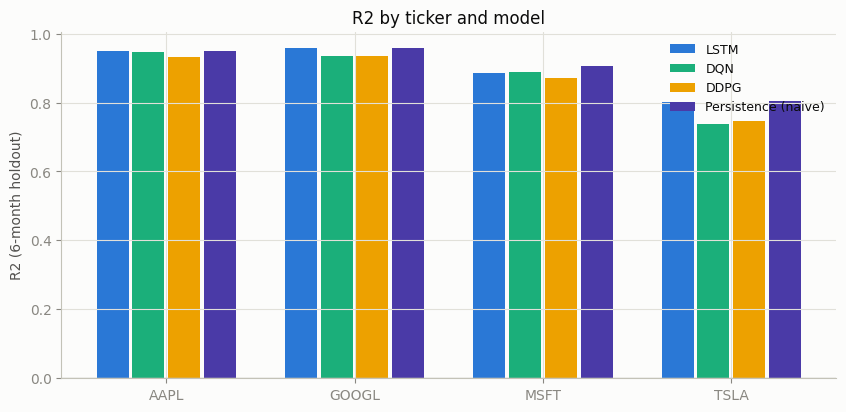

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.5))
models = ["LSTM", "DQN", "DDPG", "Persistence (naive)"]
colors = [COLORS["blue"], COLORS["aqua"], COLORS["yellow"], COLORS["violet"]]
tickers = list(r2_summary.index)
xpos = np.arange(len(tickers))
for j, (mdl, col) in enumerate(zip(models, colors)):
    ax.bar(xpos + (j - 1.5) * 0.19, r2_summary[mdl].values, width=0.17,
           color=col, label=mdl)
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels(tickers)
ax.set_ylabel("R2 (6-month holdout)")
ax.set_title("R2 by ticker and model")
ax.legend(fontsize=9)
save_fig(fig, "10_r2_by_ticker.png")
plt.show()

## 10 — Results & discussion

**R².** All three models land within a whisker of the persistence baseline
on every ticker. Daily prices are close to a random walk, so one-step price
R² mostly rewards *tracking* — even naive "tomorrow = today" scores ~0.94 on
AAPL. The LSTM is the best learned model on every ticker; DQN and DDPG swap
places depending on the stock. A model scoring far *above* persistence would
be a sign of data leakage, not skill.

**Returns & risk.** The backtest separates the models much more than R²
does. On AAPL, buy & hold made 14.8 % over the holdout (Sharpe 1.04), DQN
8.6 % (0.69), LSTM 4.9 % (0.59) and DDPG lost 9.1 % (−0.97) — despite all
three having similar R². Hit rates are all near 50 %. On the tickers that
fell over the holdout (MSFT, TSLA) the long/flat strategies lose less than
buy & hold because they are partly in cash. So good prediction accuracy does
not automatically mean good trading performance — which is why both views
are reported.

**Lessons from earlier versions.** Scalers must be fitted on training data
only (otherwise test R² is silently inflated), and the target should be
returns rather than scaled price levels (levels can't extrapolate above the
training range).

